# The Urban Heat Island Project
This Colab notebook uses the Gemini 2.5 Flash multimodal AI model to analyze uploaded images for Urban Heat Island (UHI) risks, which are related to the 11th United Nations Sustainable Development Goal (SDG 11): Sustainable Cities and Communities. Users would need to first upload an image of their community that needs to be addressed in terms of environmental safety, and the notebook would then evaluate heat-retaining surfaces, shade availability, greenery coverage, and overall environmental safety using AI-powered image recognition. This particular project identifies dangerous urban conditions by generating safety scores and recommending cooling interventions. The notebook also converts AI observations into structured JSON data, allowing results to be organized, reusable, and easy to interpret for future applications. In the end, there are custom questioning and edge-case testing features that explore AI reasoning, bias, and decision-making in real-world civic and environmental scenarios.

# Setting Up Your Development Environment
- Install the required libraries.

In [ ]:
!pip install -q google-generativeai Pillow

# Importing and Initializing Gemini

Store your API key in Colab Secrets:
 1. Click the key icon in the left sidebar
 2. Add a secret named `GEMINI_API_KEY`
 3. Paste your API key as the value
 4. Toggle "Notebook access" to ON

Get your free API key at: https://aistudio.google.com

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os
import json

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


# Part 1: Upload Your Image

You need an image to analyze. Choose one of these options:

- **Option A** — Take a photo on your phone and upload it here.
- **Option B** — Use any existing image from your computer or downloaded from the internet.
- **Option C (recommended)** — Photograph something in your neighborhood that you believe represents a real civic or social issue. This could be a pothole, graffiti, overgrown vegetation blocking a sign, poor lighting on a path, a broken bench in a park — anything you personally think is a problem.

Supported formats: jpg, jpeg, png, gif, webp — maximum 20 MB.

> **Why Option C?** The reflection at the end of this lab asks you to compare what *you* see in the image to what the *AI* sees. Choosing a real issue you care about makes that comparison meaningful.

Saving Park.jpg.webp to Park.jpg (1).webp
Uploaded: Park.jpg (1).webp
Image size: 1400x1400 pixels


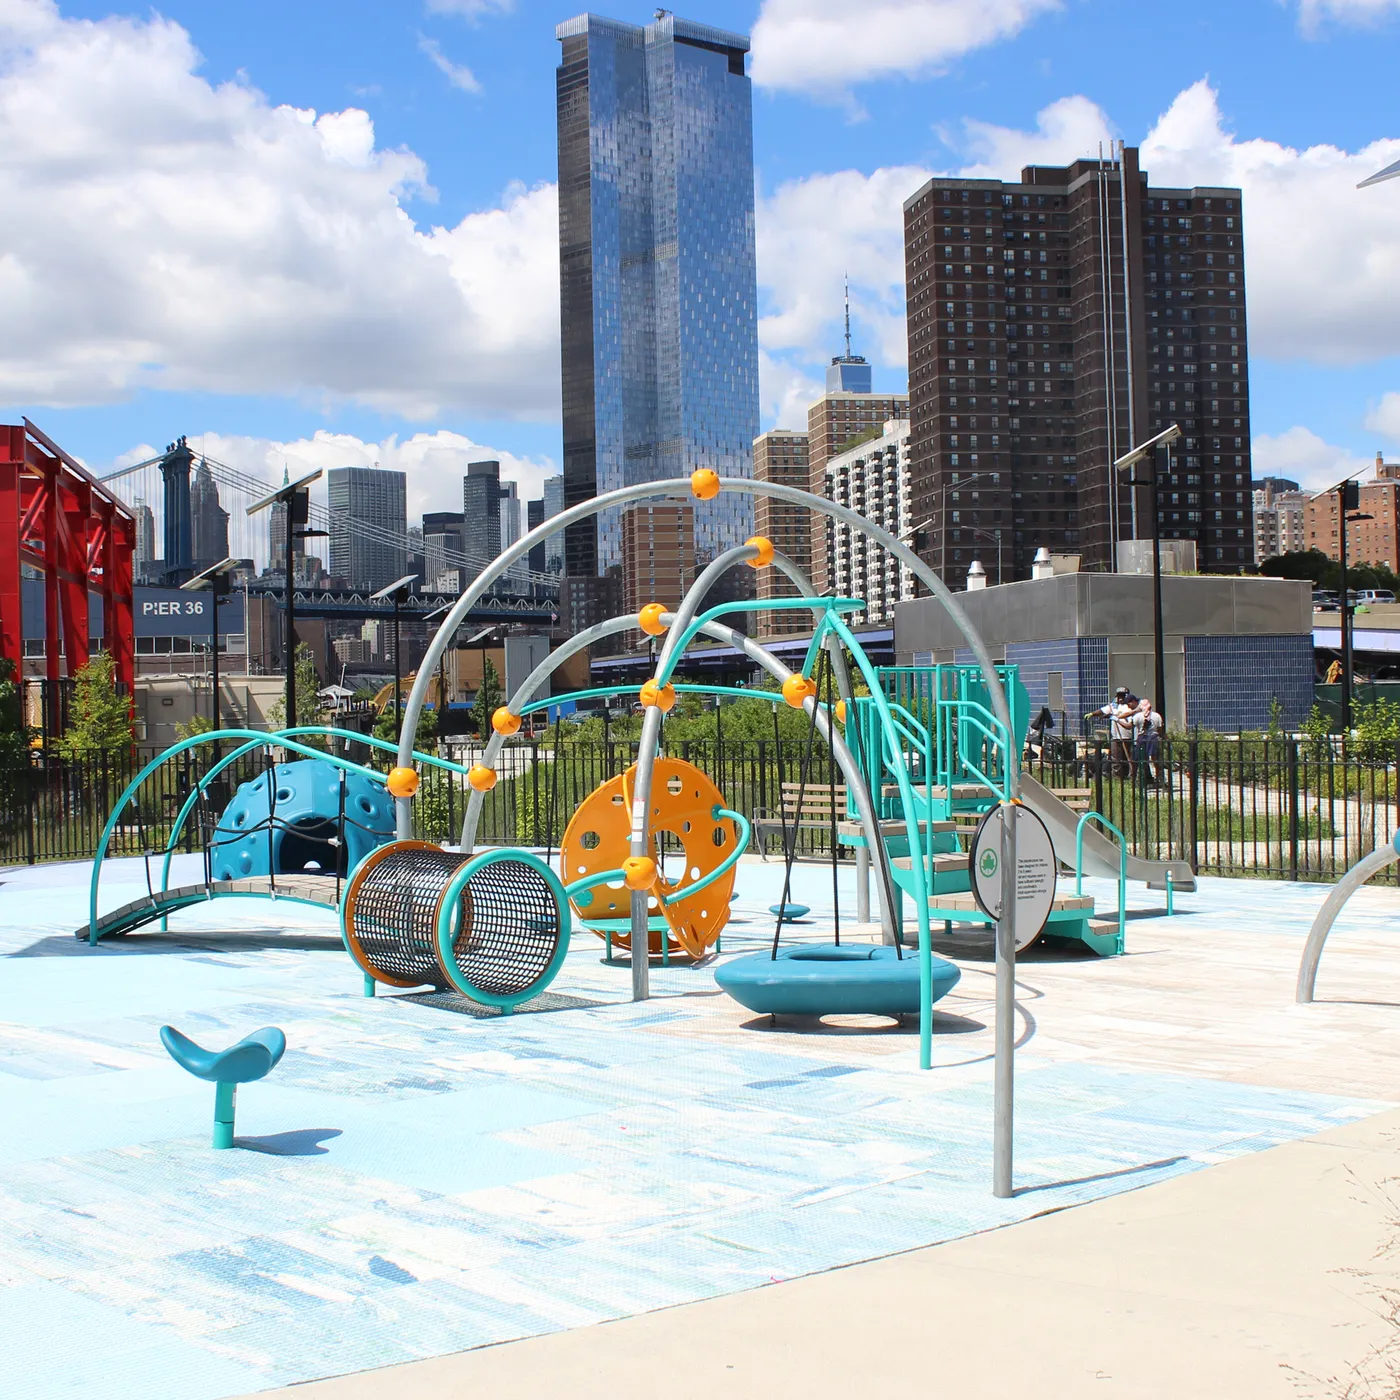

In [ ]:
# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

# Part 2: Core Analysis Function

This function sends both the image and a question to Gemini.
This is called **multimodal input** — the model processes image and text together.

Run this cell to define the function. No output yet — that comes in Part 3.

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # Increased sleep to stay under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


# Part 3: Urban Heat Island Analysis

Now, we'll use Gemini to analyze your image for factors contributing to the Urban Heat Island (UHI) effect. The questions below are designed to assess heat-retaining surfaces, green infrastructure, and overall heat risk.

Run the cell below to see how Gemini answers these questions for your image. This may take a few minutes due to rate limits — that is expected.

### Running Urban Heat Island Analysis - Question by Question

Below, each question is in its own cell. Run them one by one. If you encounter a `TooManyRequests` error, wait a minute or two before trying the next cell.

Project Proposal: The SafePlay Audit

User: Mateo, a city parent who relies on public parks but worries about heat.

Failure: City apps show park locations but hide the "invisible" 140°F ground temperature.

AI Capability: Image Recognition (identifying materials like rubber/metal and shade levels).

Workflow: Photo upload → AI Material/Shade Analysis → Safety Score → Mateo stays safe.

In [ ]:
UHI_questions = [
    ("SURFACE",  "Identify ground materials. Describe their heat absorption: use very brief points for each"),
    ("SHADE",    "Concisely describe any shade canopy from trees or structures and briefly estimate the unshaded percentage in under 50 words."),
    ("UHI_RISK", "Rate UHI risk (1-10). Very concisely explain the score based on greenery/cooling surfaces."),
    ("FIX",      "Recommend an SDG 11 intervention(s) to cool this spot.")
]
# Using Gemini 2.5 Flash for multimodal analysis of urban surface materials

UHI_results = {"answers": {}, "total_tokens": 0}

for label, question in UHI_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    UHI_results["answers"][label] = answer
    UHI_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {UHI_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- SURFACE ---
**Ground Materials:**

*   **Rubber Safety Surfacing:** The light blue and white patterned surface under the playground equipment.
*   **Concrete:** The light gray pathways bordering the playground area.
*   **Grass/Soil:** Visible in the background and through the fence, supporting some vegetation.

**Heat Absorption:**

*   **Rubber Safety Surfacing:** Moderate absorption; light blue color reflects some, but rubber itself can get warm on sunny days.
*   **Concrete:** Moderate absorption; light gray reflects some, but its density allows it to absorb and retain heat.
*   **Grass/Soil:** Low absorption; grass actively cools through evapotranspiration, and natural ground temperatures are generally moderated.

--- SHADE ---
Shade canopy is very limited, provided mainly by the playground equipment structures and sparse distant trees. The vast majority of the play area is in direct sunlight.

Unshaded percentage: ~85%

--- UHI_RISK ---
**UHI Risk: 8/10**

**Explanation:** Hi

In [ ]:
# Stores the official AI-generated Urban Heat Island (UHI) risk assessment
# so the same risk score and reasoning can be reused consistently in the structured JSON analysis

official_uhi_risk = UHI_results["answers"]["UHI_RISK"]

In [ ]:
# Structured schema for Urban Heat Island analysis

UHI_schema_prompt = """
Analyze this image for Urban Heat Island (UHI) conditions.

Return ONLY valid JSON with exactly these fields:

{
  "surface_materials": string,
  "shade_conditions": string,
  "tree_coverage_level": "LOW" or "MEDIUM" or "HIGH",
  "estimated_unshaded_percent": integer,
  "uhi_risk_score": integer,
  "risk_level": "LOW" or "MEDIUM" or "HIGH",
  "recommended_fix": string
}

Guidelines:
- surface_materials = describe pavement, asphalt, grass, rubber, concrete, mixed surfaces, etc.
- shade_conditions = summarize tree shade or structures shade exists
- tree coverage should reflect visible greenery.
- estimated_unshaded_percent = based on shade_conditions and tree_coverage_level
- uhi_risk_score = number from 1-10 and based on UHI_questions
- risk_level:
    LOW = mostly shaded/cool surfaces
    MEDIUM = mixed surfaces and limited shade
    HIGH = mostly heat-absorbing surfaces with little shade
- recommended_fix = practical cooling intervention and should suggest an SDG 11 improvement to reduce heat.

No explanation.
No markdown.
JSON only.
"""

In [ ]:
# This function performs a structured Urban Heat Island (UHI) analysis by sending the uploaded image to Gemini 2.5 Flash, reusing the previously generated UHI risk assessment, and returning the results as clean JSON data for consistent and organized reporting.

def analyze_uhi_structured(image_path):

    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=UHI_schema_prompt
    )

    img = PILImage.open(image_path)

    response = m.generate_content([
    f"""
    Analyze this image for Urban Heat Island risk.

    IMPORTANT:
    Use this official pre-generated UHI risk assessment:
    {official_uhi_risk}

    Reuse that SAME risk score and risk reasoning in the JSON output.
    Do not generate a new score.
    """,
    img
])

    time.sleep(12)

    raw = response.text.strip()

    # Remove markdown formatting if Gemini adds it
    if raw.startswith("```"):
        raw = raw.split("\n", 1)[1].rsplit("```", 1)[0].strip()

    return json.loads(raw)

# Part 4: Structured Urban Heat Island Analysis

Based on the uploaded image, the UHI results are then put into a structured Urban Heat Island analysis. Here, the AI-generated JSON results in a more organized and readable format.

In [ ]:
print("--- STRUCTURED URBAN HEAT ISLAND ANALYSIS ---")

UHI_result = analyze_uhi_structured(image_filename)

print(json.dumps(UHI_result, indent=2))

--- STRUCTURED URBAN HEAT ISLAND ANALYSIS ---
{
  "surface_materials": "Light-colored synthetic/rubber playground surfacing, surrounding concrete walkways, and dense urban infrastructure with glass and dark building materials.",
  "shade_conditions": "Minimal natural shade from young, sparse trees. The playground and immediate surrounding concrete are largely exposed to direct sunlight. Distant tall buildings offer no direct shade to the play area.",
  "tree_coverage_level": "LOW",
  "estimated_unshaded_percent": 90,
  "uhi_risk_score": 8,
  "risk_level": "HIGH",
  "recommended_fix": "Implement extensive planting of mature, shade-providing trees around the playground and walkways, and consider installing shade sails or canopies over play equipment to significantly reduce surface temperatures. Explore cool pavement technologies for surrounding concrete surfaces. This aligns with SDG 11 by creating more inclusive, safe, and sustainable public spaces."
}


# Part 5: Ask Your Own Question

Now that you have seen the standard four-question analysis, ask the model something specific
that is relevant to your own image or your team's project scenario.

Examples:
- `"Is there any graffiti or vandalism visible in this image?"`
- `"Does this sidewalk appear to be in need of repair?"`
- `"Are there any accessibility barriers visible for wheelchair users?"`
- `"What time of day does this appear to have been taken?"`
- `"What would it cost to fix what you see here?"`

In [ ]:
custom_question = input("\nAsk your own question about the image: ")
custom_result, custom_usage = analyze_image(image_filename, custom_question)

print("\n--- Response ---")
print(custom_result)
print(f"\nTokens used: {custom_usage.total_token_count}")


Ask your own question about the image: Is this playground essentially 'unusable' for children between 12:00 PM and 4:00 PM on a summer day?

--- Response ---
Based on the image and the specified conditions (12:00 PM - 4:00 PM on a summer day):

Yes, this playground would likely be **essentially unusable** or at least very uncomfortable and potentially unsafe for children during those hours on a hot summer day.

Here's why:

1.  **Direct Sun Exposure:** The image clearly shows the playground in full, direct sunlight with no visible shade from trees or built structures directly over the play equipment or the ground surface. The shadows cast by the equipment itself are short and distinct, indicating midday sun.
2.  **Lack of Shade Structures:** There are no canopies, awnings, or other shade-providing elements integrated into the playground design. The small saplings outside the fence are far too small to offer any significant shade to the play area.
3.  **Material Heat Absorption:**
    

# Part 6: Edge Case Elicitation
Testing if the AI's "Visual Bias" (liking light colors) causes a safety error.

In [ ]:
# Part 6: Edge Case Elicitation
# Testing if the AI's "Visual Bias" (liking light colors) causes a safety error.

edge_case_prompt = """
The air temperature is 98 degrees. Look at the light-colored rubber floor in this image.
Is it safe for a toddler to crawl on right now?

Give me a definitive 'Safe' or 'Dangerous' first, then explain why,
focusing specifically on why rubber stays hot regardless of its color.
"""

result, usage = analyze_image(image_filename, edge_case_prompt)
print("--- PART 6: EDGE CASE TEST ---")
print(result)

print("\nAssessment:")
print("This was a near-miss because the AI may rely on visual appearance, such as lighter colors, when judging safety, even though certain materials can still retain dangerous heat in high temperatures.")

print("\nReal-World Impact:")
print("If the AI incorrectly labels an area as safe, community members could be exposed to dangerous environmental conditions, including extreme surface heat and other safety risks.")

--- PART 6: EDGE CASE TEST ---
**Dangerous**

Even though the rubber floor is light-colored, it is **dangerous** for a toddler to crawl on right now.

Here's why, focusing specifically on why rubber stays hot regardless of its color:

While lighter colors reflect more sunlight than darker colors, which can slightly reduce the initial rate of heat absorption, this effect is often insufficient to prevent rubber playground surfaces from reaching dangerously high temperatures on a hot, sunny day. At an air temperature of 98 degrees Fahrenheit, surfaces exposed to direct sunlight can easily exceed 120-150 degrees Fahrenheit. A toddler's skin is much more sensitive than an adult's and can sustain serious burns in just a few seconds at temperatures above 120 degrees Fahrenheit.

The primary reason rubber surfaces stay hot, even light-colored ones, is due to their **thermal properties**:

1.  **Low Thermal Conductivity (Insulation):** Rubber is a poor conductor of heat. This means that once th

# 4.1 One Failure Case Input:
A photo of a playground with blue rubber floors on a 98°F day. The Result: Our Part 6 run was successful, but it revealed a "Logic Gap." In Part 3, the AI was "Visually Optimistic" because of the light color. It only admitted the 120-130°F burn risk when we forced it to consider the 98°F air temperature. The Risk: If Mateo just uses the "Standard" AI without inputting the exact weather, he might get a "Safe" rating based on color alone. The failure is that the AI's safety depends entirely on how "smart" the user's question is.

# 4.2 Oversight Decision Our Position:
The AI must support, not replace, a human inspector. Justification: The AI uses words like "potentially" and "could." Because it isn't actually at the park, it's just making an educated guess. A human inspector needs to verify these scores during the hottest months to ensure the "Safe" labels are 100% accurate.

# 4.3 The One Change The Change:
Link the AI directly to local weather station data so it automatically knows the temperature without Mateo having to type it in. The Cost: This requires a paid API subscription and technical integration. It's more expensive than a basic chatbot, but it removes the "human error" of Mateo forgetting to check the weather

# Part 7: Reflection — What the AI Sees vs. What You See

**Write your answers directly in this text cell. Double-click to edit it.**

This is the most important part of the lab. Read your AI outputs carefully before answering.

---

**Question 1 — Comparison:**
Look at the AI's PROBLEM and URGENCY answers.
Do they match your own assessment of the image?
Describe at least one specific thing the AI got right and one thing it missed or misjudged.

Answer: When running the AI, I would say that it mostly matched our evaluation of the image that we chose as a group because it correctly identified heat-retaining surfaces, such as rubber, asphalt, or concrete. It also recognized the lack of shade as a major Urban Heat Island risk. The other thing that I would note is that it correctly explained that limited greenery increases surface temperatures and makes the environment less safe during hot weather. Nevertheless, the AI initially underestimated how dangerous the light-colored rubber flooring could become in extreme heat, which to us showed that it relied too much on visual appearance instead of truly understanding the real surface temperature of the image we chose for this project.

---

**Question 2 — What the model was trained to see:**
The AI's analysis reflects patterns from its training data.
If you photographed something that is a real problem in your community but
looks ordinary (for example, a sidewalk that has never had curb cuts for wheelchair users),
would the AI recognize it as a problem? What does this tell you about whose problems
get encoded into AI systems — and whose don't?

Answer: We feel as though even if there are significant problems in a community, the AI might not be able to identify them if they appear visually normal. A badly constructed crosswalk or a sidewalk lacking wheelchair curb cuts, for instance, can seem "normal" to the AI because those issues are underrepresented in training data. This demonstrates that while less obvious community issues impacting accessibility, fairness, or long-term safety may go unnoticed, AI systems have a tendency to capture issues that are visually evident or frequently documented.

---

**Question 3 — Deployment decision:**
Imagine this system is deployed: a resident uploads a photo to the San Jose 311 app,
the AI analyzes it automatically, and a work order is generated without any human review.
For what types of images or issues would this work well?
For what types would automated routing be a mistake?
Who should make that call, and how?

Answer: Graffiti, potholes, excessive heat exposure, broken equipment, and unlawful dumping are just some examples of issues that would be well-suited for this approach because they can be easily identified from photos. However, fully automated routing would be dangerous for problems that call for human judgment, such as obstacles to accessibility, structural safety issues, or circumstances when weather and context are important. For this reason, we believe that even if AI has advanced significantly, human reviewers, city inspectors, or qualified personnel should ultimately decide by confirming the AI's findings before issuing formal work orders, particularly in high-risk safety scenarios.